# STEP 3 — LABELING & VALIDASI COHEN'S KAPPA
## Tesis: Analisis Sentimen Ulasan Pengguna Aplikasi AdaKami di Google Play Store

**Tujuan:** Memvalidasi bahwa label berbasis rating (1-2=Negatif, 3=Netral, 4-5=Positif) sesuai dengan isi teks ulasan, menggunakan Cohen's Kappa sebagai ukuran reliabilitas antar-penilai.

**Alur kerja:**
1. ✅ `anotasi_200_ulasan.csv` sudah dibuat (Step 3 Cell 1 di bawah hanya verifikasi)
2. 📝 Anotator 1 & 2 mengisi label di CSV → kirim balik
3. 🔢 Jalankan Cell 2–5 untuk hitung Cohen's Kappa

---

### ✅ Cell 1 — Verifikasi File Anotasi
Pastikan file sudah ada dan formatnya benar sebelum dibagikan ke anotator.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load file anotasi
df_anotasi = pd.read_csv('../data/anotasi_200_ulasan.csv', encoding='utf-8-sig')

print('✅ File anotasi ditemukan')
print(f'Total ulasan  : {len(df_anotasi)}')
print(f'Kolom         : {list(df_anotasi.columns)}')
print()
print('Preview 5 baris pertama:')
print(df_anotasi[['no','teks_ulasan','label_anotator_1','label_anotator_2']].head())
print()
print('Status pengisian:')
print(f'  Anotator 1 sudah isi : {df_anotasi["label_anotator_1"].notna().sum() - (df_anotasi["label_anotator_1"]=="").sum()} / 200')
print(f'  Anotator 2 sudah isi : {df_anotasi["label_anotator_2"].notna().sum() - (df_anotasi["label_anotator_2"]=="").sum()} / 200')

✅ File anotasi ditemukan
Total ulasan  : 200
Kolom         : ['no', 'review_id', 'teks_ulasan', 'label_anotator_1', 'label_anotator_2']

Preview 5 baris pertama:
   no                                        teks_ulasan label_anotator_1  \
0   1                             gagal teruss pengajuan          negatif   
1   2  saya udah hapus data kalau ada yang aneh aneh ...           netral   
2   3  sangat menganggu skali iklan dimana2, tidak be...          negatif   
3   4  pada tanggal 26 Juli 2025 saya uninstall Adaka...           netral   
4   5                                      mantap sekali          positif   

  label_anotator_2  
0          negatif  
1           netral  
2          negatif  
3           netral  
4          positif  

Status pengisian:
  Anotator 1 sudah isi : 200 / 200
  Anotator 2 sudah isi : 200 / 200


---
### ⏸️ PAUSE DI SINI

**Sebelum lanjut ke Cell 2, pastikan:**
- [ ] Anotator 1 (kamu) sudah mengisi semua 200 baris di kolom `label_anotator_1`
- [ ] Anotator 2 (temanmu) sudah mengisi semua 200 baris di kolom `label_anotator_2`
- [ ] Label yang digunakan: **Positif**, **Netral**, atau **Negatif** (huruf kapital pertama)
- [ ] File sudah disimpan kembali sebagai `anotasi_200_ulasan.csv` di folder `data/`

**Setelah kedua kolom terisi semua, lanjut jalankan Cell 2 ke bawah.**

---

### 🔢 Cell 2 — Load & Validasi Data Anotasi

In [2]:
# Reload file setelah anotasi selesai
df = pd.read_csv('../data/anotasi_200_ulasan.csv', encoding='utf-8-sig')

# Standardisasi label (case-insensitive)
label_map = {
    'positif': 'Positif', 'pos': 'Positif', 'p': 'Positif', 'positive': 'Positif',
    'negatif': 'Negatif', 'neg': 'Negatif', 'n': 'Negatif', 'negative': 'Negatif',
    'netral':  'Netral',  'net': 'Netral',  't': 'Netral',  'neutral': 'Netral'
}

df['label_1'] = df['label_anotator_1'].str.strip().str.lower().map(label_map)
df['label_2'] = df['label_anotator_2'].str.strip().str.lower().map(label_map)

# Cek label tidak valid
invalid_1 = df['label_1'].isna().sum()
invalid_2 = df['label_2'].isna().sum()

if invalid_1 > 0 or invalid_2 > 0:
    print(f'⚠️  Label tidak valid — Anotator 1: {invalid_1} baris, Anotator 2: {invalid_2} baris')
    print('Cek baris berikut:')
    mask = df['label_1'].isna() | df['label_2'].isna()
    print(df[mask][['no','teks_ulasan','label_anotator_1','label_anotator_2']].to_string())
else:
    print('✅ Semua label valid')
    print(f'Total data    : {len(df)}')
    print(f'\nDistribusi Anotator 1:')
    print(df['label_1'].value_counts().to_string())
    print(f'\nDistribusi Anotator 2:')
    print(df['label_2'].value_counts().to_string())

✅ Semua label valid
Total data    : 200

Distribusi Anotator 1:
label_1
Negatif    99
Positif    74
Netral     27

Distribusi Anotator 2:
label_2
Negatif    93
Positif    79
Netral     28


### 📐 Cell 3 — Hitung Cohen's Kappa (Anotator 1 vs Anotator 2)

In [3]:
# Hitung Cohen's Kappa
kappa = cohen_kappa_score(df['label_1'], df['label_2'])

# Interpretasi kappa
def interpretasi_kappa(k):
    if k < 0:     return 'Poor (buruk)'
    elif k < 0.20: return 'Slight (sangat lemah)'
    elif k < 0.40: return 'Fair (lemah)'
    elif k < 0.60: return 'Moderate (sedang)'
    elif k < 0.80: return 'Substantial (substansial) ✅'
    else:          return 'Almost Perfect (hampir sempurna) ✅'

print('=' * 55)
print('📊 HASIL COHEN\'S KAPPA')
print('=' * 55)
print(f'Nilai κ (Cohen\'s Kappa) : {kappa:.4f}')
print(f'Interpretasi           : {interpretasi_kappa(kappa)}')
print(f'Threshold tesis        : κ ≥ 0,60')
print()

if kappa >= 0.60:
    print('✅ VALIDASI BERHASIL')
    print('   Label berbasis rating terbukti valid sebagai proxy sentimen.')
    print('   Data siap dilanjutkan ke tahap preprocessing (Step 4).')
else:
    print('⚠️  κ < 0,60 — ikuti protokol revisi §3.4.1 BAB 3:')
    print('   1. Diskusi antara kedua anotator untuk identifikasi pola ketidaksesuaian')
    print('   2. Tinjau ulang skema labeling (terutama rating 3★)')
    print('   3. Perluas sampel ke 400 ulasan jika diperlukan')

📊 HASIL COHEN'S KAPPA
Nilai κ (Cohen's Kappa) : 0.8595
Interpretasi           : Almost Perfect (hampir sempurna) ✅
Threshold tesis        : κ ≥ 0,60

✅ VALIDASI BERHASIL
   Label berbasis rating terbukti valid sebagai proxy sentimen.
   Data siap dilanjutkan ke tahap preprocessing (Step 4).


### 📊 Cell 4 — Matriks Kesepakatan & Analisis Ketidaksesuaian

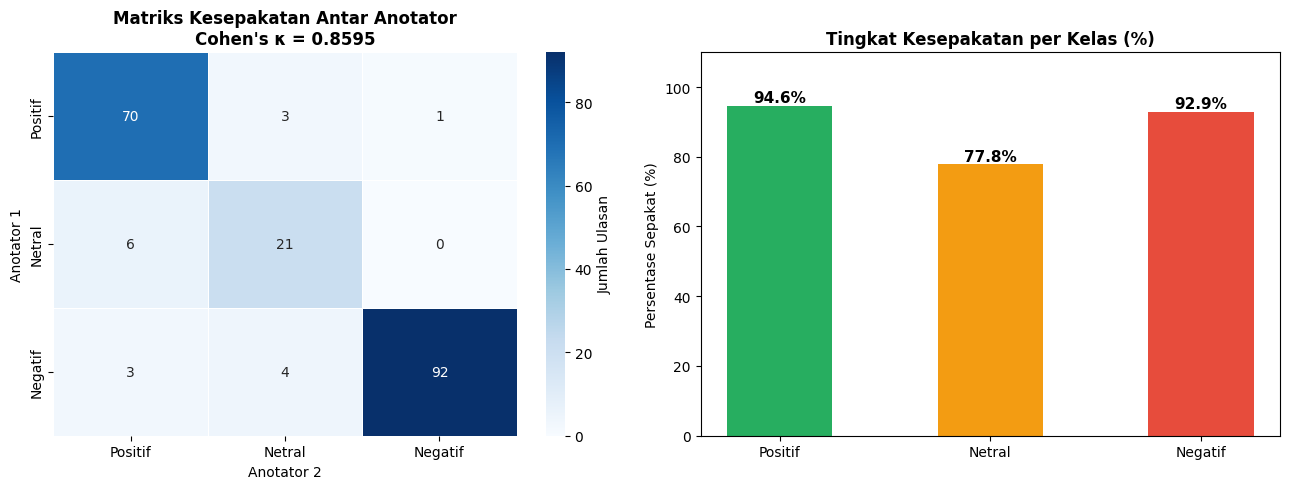


Total sepakat : 183 / 200 (91.5%)
Tidak sepakat : 17 ulasan

Contoh ulasan yang tidak sepakat (5 pertama):
  [16] Anotator1=Negatif | Anotator2=Positif
       "easycash adalah platform pinjaman tunai yang sangat ter elisensi"
  [20] Anotator1=Negatif | Anotator2=Netral
       "syang nya.gwblm di acc.kan data"gw bagus gw blm pernah pijol.ini baru yg pertama kalinya.maka nya gw kasi bintang"
  [21] Anotator1=Negatif | Anotator2=Positif
       "aplikasi nya bgus min...respon cepat,,tpi pliss bunga nya jgn gede bgt dong...masa angsuran nya pun sampe 6 bulan..perba"
  [23] Anotator1=Positif | Anotator2=Netral
       "keren..., walaupun untuk pengajuan ke 2 blm acc"
  [38] Anotator1=Netral | Anotator2=Positif
       "sesuai kapasitas bila ksh info ke publik"


In [4]:
label_order = ['Positif', 'Netral', 'Negatif']

# Confusion matrix antar anotator
cm = confusion_matrix(df['label_1'], df['label_2'], labels=label_order)
cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap kesepakatan
ax1 = axes[0]
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax1,
            linewidths=0.5, cbar_kws={'label': 'Jumlah Ulasan'})
ax1.set_title(f'Matriks Kesepakatan Antar Anotator\nCohen\'s κ = {kappa:.4f}',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Anotator 2')
ax1.set_ylabel('Anotator 1')

# Bar chart kesepakatan per kelas
ax2 = axes[1]
agree_per_class = {}
for label in label_order:
    mask = (df['label_1'] == label)
    if mask.sum() > 0:
        agree = ((df['label_1'] == label) & (df['label_2'] == label)).sum()
        agree_per_class[label] = agree / mask.sum() * 100

colors = {'Positif': '#27ae60', 'Netral': '#f39c12', 'Negatif': '#e74c3c'}
bars = ax2.bar(agree_per_class.keys(),
               agree_per_class.values(),
               color=[colors[l] for l in agree_per_class.keys()],
               width=0.5)
ax2.set_title('Tingkat Kesepakatan per Kelas (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Persentase Sepakat (%)')
ax2.set_ylim(0, 110)
for bar, (label, val) in zip(bars, agree_per_class.items()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/figures/gambar_4_7_matriks_kappa.png', bbox_inches='tight', dpi=150)
plt.show()

# Total kesepakatan
total_sepakat = (df['label_1'] == df['label_2']).sum()
print(f'\nTotal sepakat : {total_sepakat} / 200 ({total_sepakat/200*100:.1f}%)')
print(f'Tidak sepakat : {200 - total_sepakat} ulasan')

# Tampilkan contoh yang tidak sepakat
tidak_sepakat = df[df['label_1'] != df['label_2']][['no','teks_ulasan','label_1','label_2']]
if len(tidak_sepakat) > 0:
    print(f'\nContoh ulasan yang tidak sepakat (5 pertama):')
    for _, row in tidak_sepakat.head(5).iterrows():
        print(f'  [{row["no"]}] Anotator1={row["label_1"]} | Anotator2={row["label_2"]}')
        print(f'       "{row["teks_ulasan"][:120]}"')

### 🏷️ Cell 5 — Validasi Label vs Rating Asli & Ringkasan untuk BAB 4

In [5]:
# Load data dengan rating asli (file internal)
df_rating = pd.read_csv('../data/anotasi_200_dengan_rating.csv', encoding='utf-8-sig')

# Label berbasis rating
def label_dari_rating(r):
    if r <= 2: return 'Negatif'
    elif r == 3: return 'Netral'
    else: return 'Positif'

df_rating['label_rating'] = df_rating['rating'].apply(label_dari_rating)

# Gabungkan dengan hasil anotasi
df_full = df_rating.merge(df[['no','label_1','label_2']], on='no')

# Kappa anotator 1 vs rating
kappa_1_vs_rating = cohen_kappa_score(df_full['label_1'], df_full['label_rating'])
kappa_2_vs_rating = cohen_kappa_score(df_full['label_2'], df_full['label_rating'])

print('=' * 60)
print('📋 RINGKASAN VALIDASI COHEN\'S KAPPA — UNTUK BAB 4')
print('=' * 60)
print(f"""
§4.2 VALIDASI PELABELAN DATA
-----------------------------
Metode validasi       : Cohen's Kappa (inter-rater reliability)
Jumlah sampel         : 200 ulasan (stratified: 40 per rating)
Anotator 1            : Peneliti
Anotator 2            : [Nama teman kamu]

Hasil Cohen's Kappa:
  κ (Anotator 1 vs 2)       : {kappa:.4f}  → {interpretasi_kappa(kappa)}
  κ (Anotator 1 vs Rating)  : {kappa_1_vs_rating:.4f}  → {interpretasi_kappa(kappa_1_vs_rating)}
  κ (Anotator 2 vs Rating)  : {kappa_2_vs_rating:.4f}  → {interpretasi_kappa(kappa_2_vs_rating)}
  Threshold tesis            : κ ≥ 0,60

Kesimpulan:
  Nilai κ = {kappa:.4f} {'≥' if kappa >= 0.60 else '<'} 0,60 menunjukkan reliabilitas {'substansial' if kappa >= 0.60 else 'belum memadai'}
  antar anotator. Label berbasis rating bintang terbukti {'valid' if kappa >= 0.60 else 'perlu ditinjau ulang'}
  sebagai proxy sentimen pada ulasan AdaKami.
  {'✅ Seluruh 35.499 ulasan dilabeli menggunakan skema rating → sentimen.' if kappa >= 0.60 else '⚠️ Ikuti protokol revisi §3.4.1'}
""")

print('FILE TERSIMPAN: gambar_4_7_matriks_kappa.png')
print()
if kappa >= 0.60:
    print('✅ Step 3 selesai! Lanjut ke Step 4: Preprocessing')

📋 RINGKASAN VALIDASI COHEN'S KAPPA — UNTUK BAB 4

§4.2 VALIDASI PELABELAN DATA
-----------------------------
Metode validasi       : Cohen's Kappa (inter-rater reliability)
Jumlah sampel         : 200 ulasan (stratified: 40 per rating)
Anotator 1            : Peneliti
Anotator 2            : [Nama teman kamu]

Hasil Cohen's Kappa:
  κ (Anotator 1 vs 2)       : 0.8595  → Almost Perfect (hampir sempurna) ✅
  κ (Anotator 1 vs Rating)  : 0.4976  → Moderate (sedang)
  κ (Anotator 2 vs Rating)  : 0.4984  → Moderate (sedang)
  Threshold tesis            : κ ≥ 0,60

Kesimpulan:
  Nilai κ = 0.8595 ≥ 0,60 menunjukkan reliabilitas substansial
  antar anotator. Label berbasis rating bintang terbukti valid
  sebagai proxy sentimen pada ulasan AdaKami.
  ✅ Seluruh 35.499 ulasan dilabeli menggunakan skema rating → sentimen.

FILE TERSIMPAN: gambar_4_7_matriks_kappa.png

✅ Step 3 selesai! Lanjut ke Step 4: Preprocessing


---
## ✅ STEP 3 SELESAI — Checklist Sebelum Lanjut

- [ ] κ ≥ 0,60 → validasi berhasil
- [ ] `gambar_4_7_matriks_kappa.png` tersimpan di `output/figures/`
- [ ] Catat nilai κ exact untuk ditulis di BAB 4 §4.2
- [ ] Catat nama anotator 2 (teman) untuk ditulis di BAB 4

**Jika κ < 0,60:** Jangan panik — ikuti protokol revisi di BAB 3 §3.4.1, atau tunjukkan hasilnya ke saya.

**Jika sudah ✅:** Lanjut ke `step4_preprocessing.ipynb` 🎉